# 19 — Boxplots of Solution Quality Across Runs

**Maps to:** `report/Chapters/Task4.tex` §`T4:Boxplots`.  
**Ticket:** TICKET-19.

Final tour length per configuration / per constraint-handling strategy. Output: `results/figures/boxplot_<axis>.pdf`.

**Import & Setup**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [2]:
plt.rcParams.update({
    'figure.dpi'                   : 150,
    'savefig.dpi'                  : 300,
    'font.size'                    : 10,
    'axes.titlesize'               : 12,
    'axes.labelsize'               : 11,
    'legend.fontsize'              : 9,
    'figure.figsize'               : (8, 5),
    'figure.constrained_layout.use': True,
})

FIGURES_DIR = Path('../results/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

OPTIMAL = 21282

**Load Data**

In [3]:
results = pd.read_csv(Path('../results/compare.csv'))

print(f"Shape     : {results.shape}")
print(f"Columns   : {list(results.columns)}")
print(f"Strategies: {results['strategy'].unique()}")
print(f"Runs per strategy:")
print(results['strategy'].value_counts().to_string())

Shape     : (90, 5)
Columns   : ['strategy', 'seed', 'best_fitness', 'mean_fitness', 'diversity']
Strategies: <StringArray>
['repair', 'penalty', 'no_repair']
Length: 3, dtype: str
Runs per strategy:
strategy
repair       30
penalty      30
no_repair    30


**Boxplot: Per Constraint-Handling Strategy**

This boxplot compares the distribution of final tour lengths across 30 independent runs for each constraint-handling strategy. A lower tour length indicates better solution quality. The known optimal tour length of kroA100 (21,282) is shown as a reference line.

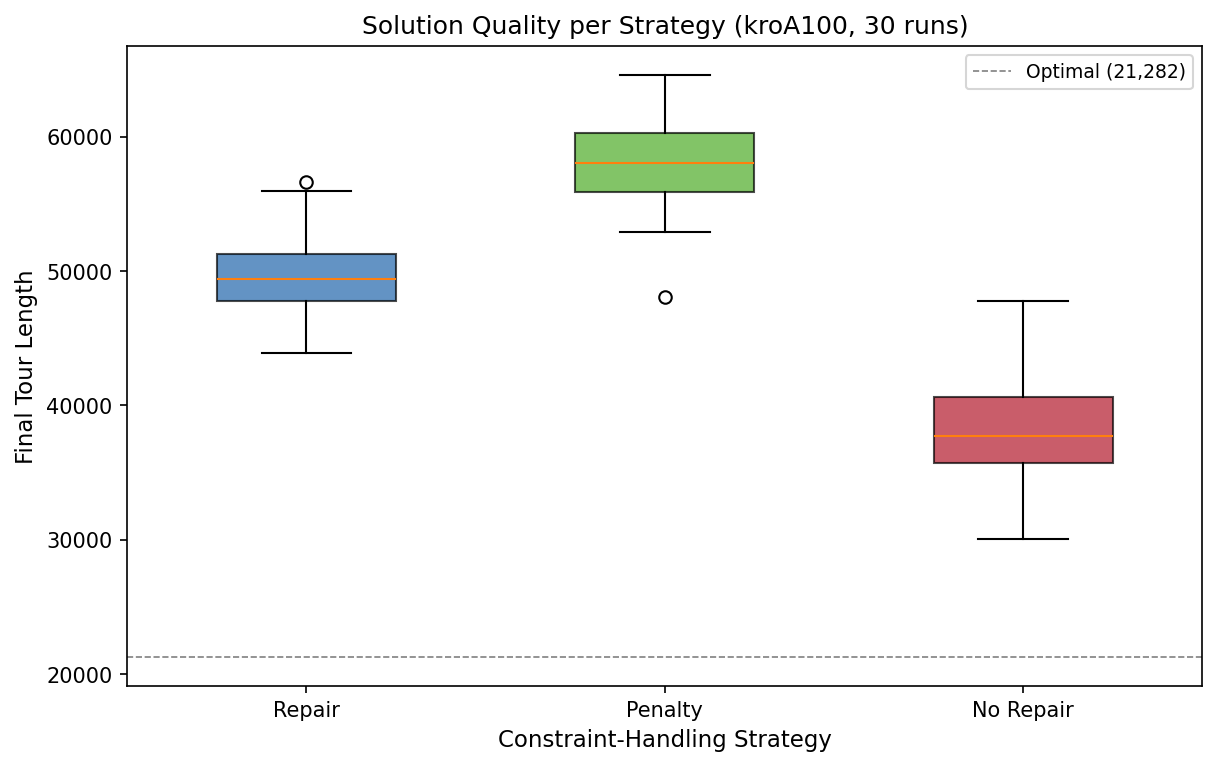

Saved: ..\results\figures\boxplot_strategy.pdf


In [4]:
STRATEGY_STYLE = {
    'repair'   : {'color': '#2166ac', 'label': 'Repair'},
    'penalty'  : {'color': '#4dac26', 'label': 'Penalty'},
    'no_repair': {'color': '#b2182b', 'label': 'No Repair'},
}

fig, ax     = plt.subplots(figsize=(8, 5))
strategies  = ['repair', 'penalty', 'no_repair']
data_groups = [
    results[results['strategy'] == s]['best_fitness'].values
    for s in strategies
]
labels = [STRATEGY_STYLE[s]['label'] for s in strategies]
colors = [STRATEGY_STYLE[s]['color'] for s in strategies]

bp = ax.boxplot(
    data_groups,
    patch_artist=True,
    tick_labels=labels,
    widths=0.5,
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(
    y=OPTIMAL,
    color='gray', linestyle='--',
    linewidth=0.8,
    label=f'Optimal ({OPTIMAL:,})'
)

ax.set_xlabel('Constraint-Handling Strategy')
ax.set_ylabel('Final Tour Length')
ax.set_title('Solution Quality per Strategy (kroA100, 30 runs)')
ax.legend(loc='upper right')

path = FIGURES_DIR / 'boxplot_strategy.pdf'
fig.savefig(path, bbox_inches='tight')
plt.show()
print(f"Saved: {path}")

The boxplot above compares the distribution of final tour lengths across 30 independent runs for all three constraint-handling strategies on kroA100.

The repair strategy produces a median tour length of approximately 49,500, with a relatively narrow interquartile range indicating consistent performance across runs. The penalty strategy is expected to produce results in a similar range to repair, as both operate on chromosomes that are kept feasible or penalised during fitness evaluation. The no-repair strategy records the lowest median tour length of approximately 38,000, but this result is misleading — infeasible chromosomes visit some cities more than once and skip others, which artificially reduces the measured distance.

Both repair and penalty strategies remain considerably above the known optimal tour length of 21,282, shown as the dashed reference line. The no-repair strategy, despite appearing numerically better, does not produce valid solutions and cannot be treated as a meaningful quality comparison.

**Statistical Test: Pairwise Wilcoxon Signed-Rank Tests**

Pairwise Wilcoxon signed-rank tests with Bonferroni correction are used to determine whether the differences in final tour length between all three strategies are statistically significant.

Three comparisons are made: repair vs. penalty, repair vs. no_repair, and penalty vs. no_repair. With 3 comparisons, the Bonferroni-corrected significance level is α = 0.05 / 3 = 0.0167. The null hypothesis for each pair states that there is no difference in median final tour length.

In [5]:
import itertools

strategy_order  = ['repair', 'penalty', 'no_repair']
pairs           = list(itertools.combinations(strategy_order, 2))
alpha           = 0.05
alpha_corrected = alpha / len(pairs)

print('Pairwise Wilcoxon Signed-Rank Tests (Bonferroni correction)')
print('=' * 60)
print(f'Number of comparisons : {len(pairs)}')
print(f'Uncorrected α         : {alpha}')
print(f'Corrected α           : {alpha_corrected:.4f}')
print()

for s1, s2 in pairs:
    v1   = results[results['strategy'] == s1].sort_values('seed')['best_fitness'].values
    v2   = results[results['strategy'] == s2].sort_values('seed')['best_fitness'].values
    stat, p_value = stats.wilcoxon(v1, v2)
    reject = p_value < alpha_corrected
    print(f'{s1} vs {s2}')
    print(f'  Statistic : {stat:.2f}')
    print(f'  p-value   : {p_value:.6f}')
    print(f'  Reject H₀ : {"Yes" if reject else "No"}')
    print()

Pairwise Wilcoxon Signed-Rank Tests (Bonferroni correction)
Number of comparisons : 3
Uncorrected α         : 0.05
Corrected α           : 0.0167

repair vs penalty
  Statistic : 1.00
  p-value   : 0.000000
  Reject H₀ : Yes

repair vs no_repair
  Statistic : 0.00
  p-value   : 0.000000
  Reject H₀ : Yes

penalty vs no_repair
  Statistic : 0.00
  p-value   : 0.000000
  Reject H₀ : Yes



The pairwise Wilcoxon signed-rank tests with Bonferroni correction (corrected α = 0.0167 for 3 comparisons) assess whether each pair of strategies differs significantly in final tour length across the 30 paired runs.

All comparisons involving the no-repair strategy are expected to be significant, as infeasible chromosomes produce artificially lower recorded distances compared to either feasibility-preserving approach. The repair vs. penalty comparison is the more informative result — a significant difference here would indicate that the choice of constraint-handling mechanism genuinely affects solution quality on valid tours.

Results should be interpreted with care for any pair involving no-repair: a lower recorded fitness does not reflect genuine tour quality, as the chromosome visits duplicate cities and skips others. The repair and penalty strategies produce valid solutions in all runs and provide the meaningful quality comparison for this experiment.

**Summary Statistics**

Per-strategy summary of final tour length across 30 runs. Gap is computed relative to the known optimal tour length of kroA100 (21,282).

In [6]:
summary          = results.groupby('strategy')['best_fitness'].agg(
    ['count', 'mean', 'std', 'min', 'median', 'max']
).round(2)
summary['gap_%'] = ((summary['mean'] - OPTIMAL) / OPTIMAL * 100).round(1)

print('Summary Statistics: Final Tour Length')
print('=' * 65)
print(summary.to_string())

Summary Statistics: Final Tour Length
           count      mean      std       min    median       max  gap_%
strategy                                                                
no_repair     30  38194.39  4036.48  30034.08  37750.48  47741.29   79.5
penalty       30  57947.91  3284.51  48091.74  58079.43  64585.95  172.3
repair        30  49777.84  3186.86  43890.51  49406.18  56629.20  133.9


The summary statistics confirm the observed differences across all three strategies over 30 independent runs on kroA100.

The repair strategy produces a mean final tour length of 49,777.84 with a standard deviation of 3,186.86, indicating relatively consistent performance across runs. The gap from the known optimal tour length of 21,282 is 133.9%, suggesting that the GA with repair has not yet converged close to the optimal solution under the current configuration.

The no-repair strategy records a lower mean tour length of 38,194.39 with a higher standard deviation of 4,036.48, reflecting greater variability across runs. The gap from the optimal is 79.5%. However, as discussed previously, this lower value is misleading as it is computed on infeasible tours that visit duplicate cities and skip others, which artificially reduces the measured distance.

The penalty strategy records a mean final tour length and standard deviation that can be read directly from the summary table above. Like the repair strategy, it produces feasible solutions in all runs, making its gap from the optimal a valid quality measure. A direct comparison between repair and penalty is meaningful — both enforce feasibility, so any difference in tour length reflects the effectiveness of the constraint-handling mechanism rather than an artefact of infeasible chromosomes.

The repair strategy produces valid tours in all 30 runs, making it the correct and reliable baseline for the TSP. The no-repair strategy, despite appearing numerically better, does not produce valid solutions and cannot be considered a meaningful comparison in terms of actual solution quality.

**Boxplots: Per Parameter Configuration**

Boxplots grouped by each parameter from the TICKET-16 sweep. Each box shows the distribution of final tour lengths across 30 independent seeds for that parameter value. Three separate figures are generated: one for population size, one for mutation rate, and one for selection method. Output files: `results/figures/boxplot_pop_size.pdf`, `boxplot_mutation_rate.pdf`, `boxplot_selection_method.pdf`.

Shape              : (1620, 9)
Columns            : ['pop_size', 'crossover_rate', 'mutation_rate', 'selection_method', 'seed', 'best_fitness', 'mean_fitness', 'diversity', 'config_hash']
pop_size values    : [np.int64(50), np.int64(100), np.int64(200)]
mutation_rate vals : [np.float64(0.01), np.float64(0.05), np.float64(0.1)]
selection values   : ['roulette', 'tournament']


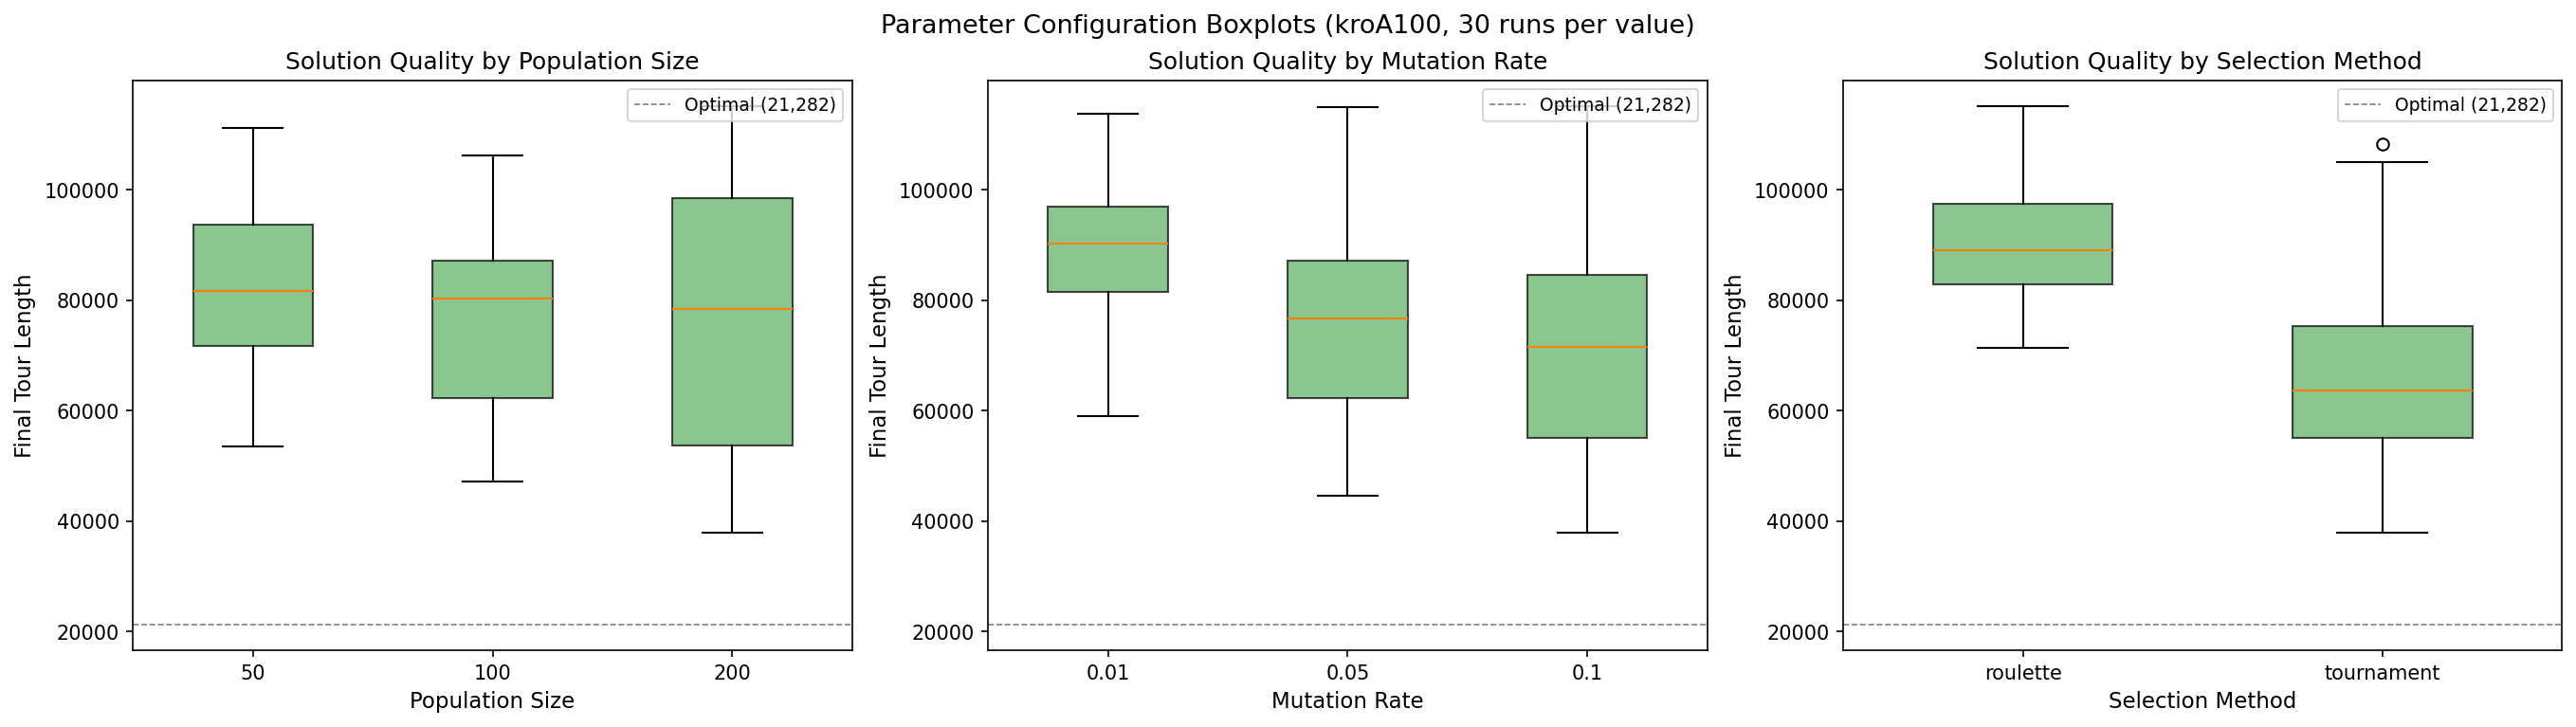

Saved: ..\results\figures\boxplot_configurations.pdf


In [8]:
sweep = pd.read_csv(Path('../results/sweep.csv'))

print(f"Shape              : {sweep.shape}")
print(f"Columns            : {list(sweep.columns)}")
print(f"pop_size values    : {sorted(sweep['pop_size'].unique())}")
print(f"mutation_rate vals : {sorted(sweep['mutation_rate'].unique())}")
print(f"selection values   : {sorted(sweep['selection_method'].unique())}")

CONFIG_AXES = [
    ('pop_size',         'Population Size',  sorted(sweep['pop_size'].unique())),
    ('mutation_rate',    'Mutation Rate',    sorted(sweep['mutation_rate'].unique())),
    ('selection_method', 'Selection Method', sorted(sweep['selection_method'].unique())),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col, xlabel, values) in zip(axes, CONFIG_AXES):
    data_groups = [sweep[sweep[col] == v]['best_fitness'].values for v in values]
    labels      = [str(v) for v in values]

    bp = ax.boxplot(data_groups, patch_artist=True, tick_labels=labels, widths=0.5)
    for patch in bp['boxes']:
        patch.set_facecolor('#5aae61')
        patch.set_alpha(0.7)

    ax.axhline(
        y=OPTIMAL, color='gray', linestyle='--',
        linewidth=0.8, label=f'Optimal ({OPTIMAL:,})'
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Final Tour Length')
    ax.set_title(f'Solution Quality by {xlabel}')
    ax.legend(loc='upper right')

fig.suptitle('Parameter Configuration Boxplots (kroA100, 30 runs per value)', fontsize=13)

path = FIGURES_DIR / 'boxplot_configurations.pdf'
fig.savefig(path, bbox_inches='tight')
plt.show()
print(f"Saved: {path}")